# Michelson (1880): Speed of Light

Michelson, as part of the US Naval Academy, sought to measure the (two-way) speed of light using a revolving mirror. The experimental setup can be found in the associated reference. Here, we apply estimating equations to re-analyze this historic data. This data can be found from a variety of online resources, including the R package `morley`.

## Setup

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import delicatessen
from delicatessen import MEstimator
from delicatessen.estimating_equations import ee_mean_robust

print("Versions")
print("NumPy:       ", np.__version__)
print("SciPy:       ", sp.__version__)
print("Pandas:      ", pd.__version__)
print("Matplotlib:  ", mpl.__version__)
print("Delicatessen:", delicatessen.__version__)

Versions
NumPy:        2.3.5
SciPy:        1.16.3
Pandas:       2.3.3
Matplotlib:   3.10.8
Delicatessen: 4.2


In [2]:
d = pd.read_csv("data/speed1879.csv")

# The copy of data comes from MASS, which has different units,
#   so we convert them to megameters per second
d['Speed'] = (d['Speed'] + 299000) / 1000

We can begin by plotting the speed of light data. Here, the units are megameters (1000 km) per second

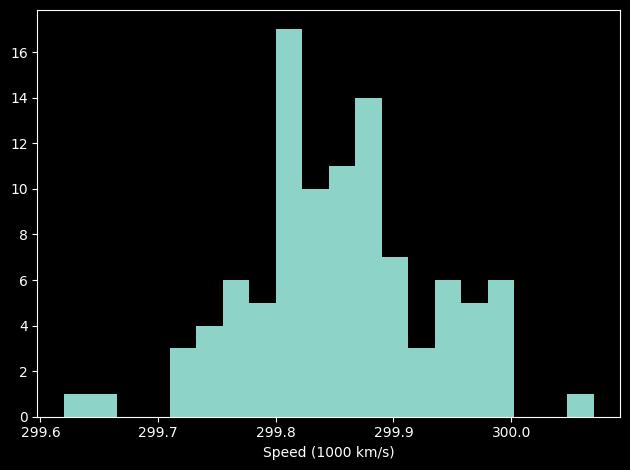

In [3]:
plt.hist(d['Speed'], bins=20)
plt.xlabel("Speed (1000 km/s)")
plt.tight_layout()

So we some variable measurements. From these observations, we will estimate the central location. This can be done using the mean of the measurements, which can be manually computed using `delicatessen` as follows

In [4]:
def psi_mean(theta):
    return d['Speed'] - theta[0]

In [5]:
estr = MEstimator(psi_mean, init=[300, ])
estr.estimate()
estr.print_results()

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:         100 | No. Parameters:              1
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
  299.85     0.01 38142.12   299.84   299.87     0.00      inf 


Therefore, we estimate the speed of light to be 299,850,000 meters per second (95% confidence interval: 299840000, 299870000). The current agreed upon speed of light is 299,792,458 m/s, so the estimate here isn't too far off.

A concern we might have from the previous plot is that there may be some undue dependence on outliers. Rather than try to remove outliers from the data, we can dampen their influence instead. This can be done by using a version of the mean robust to outliers. Here, we use Huber's proposed method. This can be done using the `ee_mean_robust` function in `delicatessen`

In [6]:
def psi_robust(theta):
    return ee_mean_robust(theta=theta, y=d['Speed'],
                          loss='huber', k=0.1)

In [7]:
estr = MEstimator(psi_robust, init=[299.85, ])
estr.estimate()
estr.print_results()

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:         100 | No. Parameters:              1
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
  299.85     0.01 36984.78   299.84   299.87     0.00      inf 


Here, we see little change when dampening the influence of potential outliers. This suggests that the deviation of the estimated speed of light is not a result of the potential outliers in the data.

## References

Michelson, A. A. (1880). Experimental determination of the velocity of light (Vol. 1). US Nautical Almanac Office.